In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import umap
import warnings
import timeit
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import scipy.stats as stats

C:\Users\thami\Documents\GitHub\TCC agrupamento\agrupamento-tcc\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
warnings.filterwarnings("ignore", message="n_jobs value 1 overridden to 1 by setting random_state")

### Leitura de dados

In [3]:
df = pd.read_csv('../dados_processados/cursos-pos-processamento.csv',sep=';')

In [4]:
df_scaled = df.drop(['no_curso','co_curso'],axis=1)

### Funções

In [5]:
barnes_hut = 'barnes_hut'
exact = 'exact'
random_state = 42

In [6]:
def reduzir_dimensionalidade_PCA(n_components):
    #Reduzir dimensionalidade com PCA
    pca = PCA(n_components=n_components, random_state=random_state)
    data_pca = pca.fit_transform(df_scaled)

    return data_pca

In [7]:
def reduzir_dimensionalidade_t_sne(n_components, method):
    #Reduzir dimensionalidade com t-SNE
    tsne = TSNE(n_components=n_components, random_state=random_state, method=method)
    data_tsne = tsne.fit_transform(df_scaled)

    return data_tsne

In [8]:
def reduzir_dimensionalidade_UMAP(n_components):
    #Reduzir dimensionalidade com UMAP
    umap_model = umap.UMAP(n_components=n_components, metric='euclidean', random_state=random_state)
    data_umap = umap_model.fit_transform(df_scaled)

    return data_umap

### Função coleta de tempos

In [9]:
def coletar_tempos_execucao(componentes, n_execucoes=50):
    """
    Coleta os tempos de execução dos métodos PCA, t-SNE e UMAP.
    
    Retorna:
    - dicionário com listas de tempos por método
    """
    tempos = {
        'PCA': [timeit.timeit(lambda: reduzir_dimensionalidade_PCA(componentes), number=1) for _ in range(n_execucoes)],
        't-SNE': [timeit.timeit(lambda: reduzir_dimensionalidade_t_sne(componentes, barnes_hut), number=1) for _ in range(n_execucoes)],
        'UMAP': [timeit.timeit(lambda: reduzir_dimensionalidade_UMAP(componentes), number=1) for _ in range(n_execucoes)],
    }
    return tempos

### Função de análise com ANOVA e TUKEY

In [10]:
def analisar_tempos_estatisticamente(tempos_dict):
    """
    Realiza ANOVA e Tukey HSD a partir de um dicionário de listas de tempos.
    """
    # Transforma o dicionário em DataFrame
    todos_tempos = []
    todos_metodos = []
    for metodo, tempos in tempos_dict.items():
        todos_tempos.extend(tempos)
        todos_metodos.extend([metodo] * len(tempos))
    
    df = pd.DataFrame({
        'tempo': todos_tempos,
        'metodo': todos_metodos
    })
    
    # ANOVA tipo II
    modelo = ols('tempo ~ metodo', data=df).fit()
    anova_tabela = sm.stats.anova_lm(modelo, typ=2)
    
    print("\n ANOVA tipo II:")
    print(anova_tabela)
    
    if anova_tabela['PR(>F)'][0] < 0.05:
        print("\n Diferença significativa encontrada — executando Tukey HSD:")
        tukey = pairwise_tukeyhsd(endog=df['tempo'], groups=df['metodo'], alpha=0.05)
        print(tukey)
        tukey.plot_simultaneous()
        plt.title("Tukey HSD")
        plt.show()
    else:
        print("\n ANOVA não significativa — métodos têm tempos semelhantes.")

### Análise tempo

In [11]:
def calcular_estatisticas(tempos_dict):
    """
    Calcula e exibe média, desvio padrão e IC 95% para cada método.
    Plota gráfico de barras com média e desvio padrão.
    """
    medias = []
    desvios = []
    metodos = []

    for metodo, tempos in tempos_dict.items():
        media = np.mean(tempos)
        desvio = np.std(tempos, ddof=1)
        n = len(tempos)
        erro = stats.sem(tempos)
        intervalo = stats.t.interval(0.95, df=n-1, loc=media, scale=erro)

        print(f"\n Estatísticas para {metodo}:")
        print(f"  Média: {media:.4f} s")
        print(f"  Desvio padrão: {desvio:.4f} s")
        print(f"  IC 95%: ({intervalo[0]:.4f}, {intervalo[1]:.4f}) s")

        metodos.append(metodo)
        medias.append(media)
        desvios.append(desvio)

    # Criando gráfico
    plt.figure(figsize=(8, 5))
    plt.bar(metodos, medias, yerr=desvios, capsize=5, color=['skyblue', 'lightgreen', 'salmon'])
    plt.ylabel("Tempo médio de execução (s)")
    plt.title("Média e Desvio Padrão dos Tempos por Método")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

### Componentes = 2


 Estatísticas para PCA:
  Média: 0.0049 s
  Desvio padrão: 0.0004 s
  IC 95%: (0.0048, 0.0050) s

 Estatísticas para t-SNE:
  Média: 29.2161 s
  Desvio padrão: 0.4509 s
  IC 95%: (29.0879, 29.3442) s

 Estatísticas para UMAP:
  Média: 6.0979 s
  Desvio padrão: 1.6687 s
  IC 95%: (5.6236, 6.5721) s


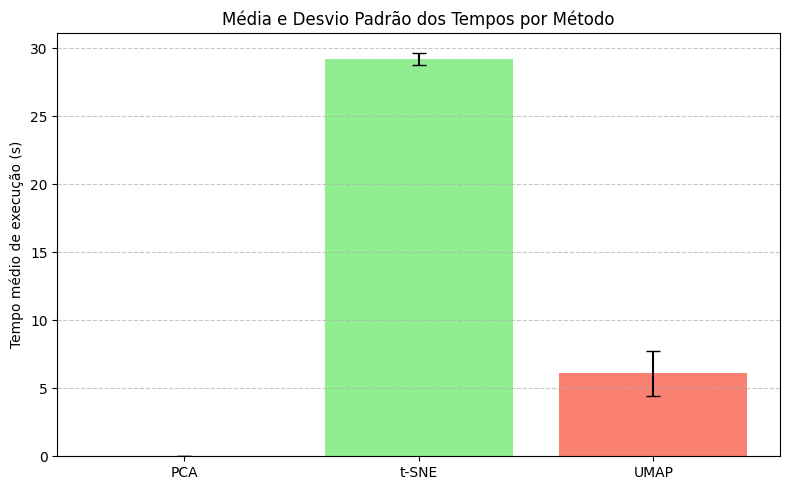


 ANOVA tipo II:
                sum_sq     df             F         PR(>F)
metodo    23747.827053    2.0  11922.883626  2.301013e-163
Residual    146.396236  147.0           NaN            NaN

 Diferença significativa encontrada — executando Tukey HSD:
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
   PCA   UMAP    6.093   0.0  5.6204  6.5656   True
   PCA  t-SNE  29.2112   0.0 28.7386 29.6838   True
  UMAP  t-SNE  23.1182   0.0 22.6456 23.5908   True
---------------------------------------------------


C:\Users\thami\AppData\Local\Temp\ipykernel_3436\1126471271.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if anova_tabela['PR(>F)'][0] < 0.05:


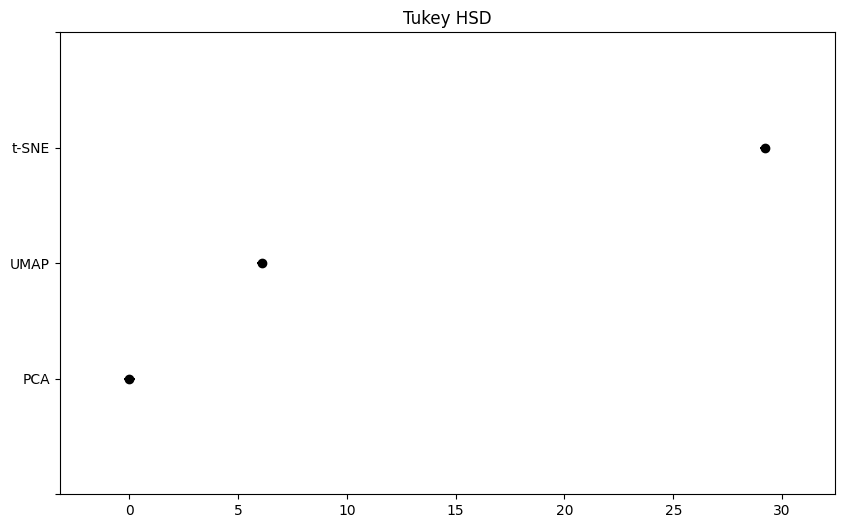

In [12]:
tempos_n_2 = coletar_tempos_execucao(2)
calcular_estatisticas(tempos_n_2)
analisar_tempos_estatisticamente(tempos_n_2)

### Componentes = 3


 Estatísticas para PCA:
  Média: 0.0049 s
  Desvio padrão: 0.0005 s
  IC 95%: (0.0048, 0.0050) s

 Estatísticas para t-SNE:
  Média: 103.1907 s
  Desvio padrão: 0.2040 s
  IC 95%: (103.1328, 103.2487) s

 Estatísticas para UMAP:
  Média: 6.0188 s
  Desvio padrão: 0.0468 s
  IC 95%: (6.0055, 6.0321) s


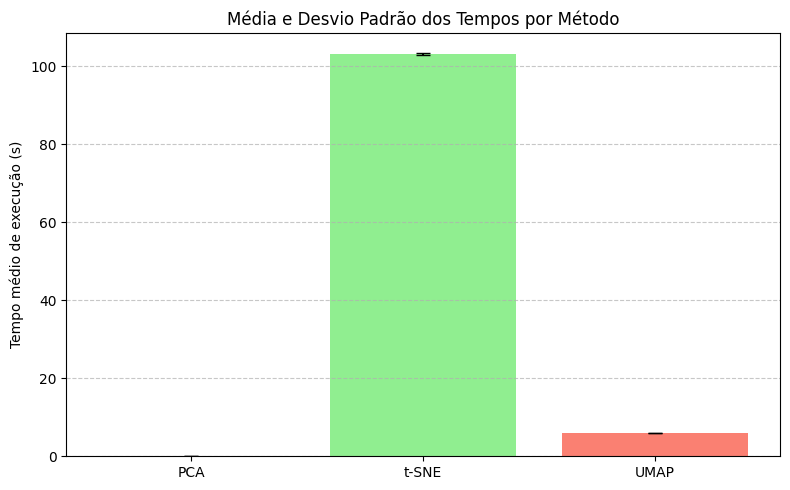


 ANOVA tipo II:
                 sum_sq     df             F  PR(>F)
metodo    335431.043320    2.0  1.148181e+07     0.0
Residual       2.147239  147.0           NaN     NaN

 Diferença significativa encontrada — executando Tukey HSD:
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj  lower    upper   reject
-----------------------------------------------------
   PCA   UMAP   6.0139   0.0   5.9567   6.0712   True
   PCA  t-SNE 103.1858   0.0 103.1286 103.2431   True
  UMAP  t-SNE  97.1719   0.0  97.1147  97.2291   True
-----------------------------------------------------


C:\Users\thami\AppData\Local\Temp\ipykernel_3436\1126471271.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if anova_tabela['PR(>F)'][0] < 0.05:


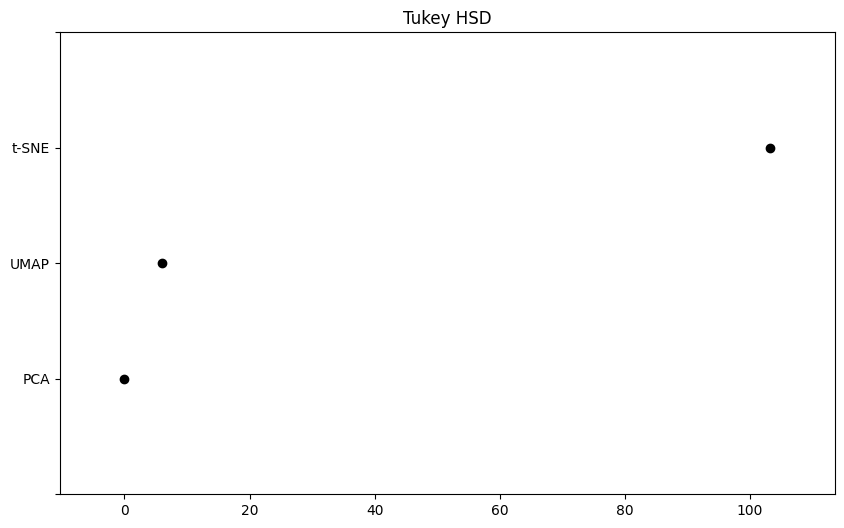

In [13]:
tempos_n_3 = coletar_tempos_execucao(3)
calcular_estatisticas(tempos_n_3)
analisar_tempos_estatisticamente(tempos_n_3)